# SHAP Explainability Analysis

This notebook explains the predictions of the trained LightGBM
late-delivery-risk model.

The goal is to identify:
- Which features influence late-delivery predictions
- Which features increase or decrease predicted risk
- Which features are most important overall
- How individual shipments receive their predictions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "outputs" / "APL_Logistics_ml_ready.csv"
MODEL_PATH = PROJECT_ROOT / "models" / "lightgbm_delay_risk_model.joblib"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Model path:", MODEL_PATH)

Project root: c:\Users\ganesh\Desktop\All Projects\Build Logistic Analysis Project
Data path: c:\Users\ganesh\Desktop\All Projects\Build Logistic Analysis Project\outputs\APL_Logistics_ml_ready.csv
Model path: c:\Users\ganesh\Desktop\All Projects\Build Logistic Analysis Project\models\lightgbm_delay_risk_model.joblib


In [3]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (180519, 37)


,Type,Days for shipment (scheduled),Benefit per order,Sales per customer,Category Id,Category Name,Customer City,Customer Country,Customer Segment,Customer State,...,Product Name,Product Price,Shipping Mode,discount_amount_per_unit,sales_per_quantity,profit_per_quantity,price_discount_interaction,scheduled_days_bucket,geo_market_region,Late_delivery_risk
0,DEBIT,4,159.69,472.45,9,Cardio Equipment,Brownsville,EE. UU.,Consumer,TX,...,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class,5.500,99.99,31.938,5.9994,4,Pacific Asia | South Asia,1
1,DEBIT,4,48.71,167.96,29,Shop By Sport,Littleton,EE. UU.,Consumer,CO,...,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class,6.398,39.99,9.742,6.3984,4,LATAM | Central America,0
2,DEBIT,4,87.36,181.99,48,Water Sports,Littleton,EE. UU.,Consumer,CO,...,Pelican Sunstream 100 Kayak,199.99,Standard Class,18.000,199.99,87.360,17.9991,4,LATAM | Central America,0
3,DEBIT,4,-41.89,175.99,48,Water Sports,Littleton,EE. UU.,Consumer,CO,...,Pelican Sunstream 100 Kayak,199.99,Standard Class,24.000,199.99,-41.890,23.9988,4,USCA | East of USA,1
4,DEBIT,4,10.00,40.00,24,Women's Apparel,Littleton,EE. UU.,Consumer,CO,...,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class,10.000,50.00,10.000,10.0000,4,USCA | East of USA,1


In [4]:
lightgbm_model = joblib.load(MODEL_PATH)

print("LightGBM model loaded successfully.")
print("Number of model features:", len(lightgbm_model.feature_name_))

LightGBM model loaded successfully.
Number of model features: 33


In [5]:
TIMING_SENSITIVE_COLUMNS = [
    "Order Profit Per Order",
    "profit_per_quantity",
    "Benefit per order"
]

TARGET = "Late_delivery_risk"

x = df.drop(columns=[TARGET], errors="ignore").copy()

x = x.drop(
    columns=TIMING_SENSITIVE_COLUMNS,
    errors="ignore"
)

y = df[TARGET].astype(int)

print("Feature matrix shape:", x.shape)
print("Target shape:", y.shape)

Feature matrix shape: (180519, 33)
Target shape: (180519,)


In [6]:
evaluation_columns = x.columns.tolist()

feature_mapping = {}

for col in evaluation_columns:
    lightgbm_name = col.replace(" ", "_")
    feature_mapping[lightgbm_name] = col

model_features = lightgbm_model.feature_name_

matched_columns = []

for model_feature in model_features:
    if model_feature in feature_mapping:
        matched_columns.append(
            feature_mapping[model_feature]
        )

print("Model features:", len(model_features))
print("Matched columns:", len(matched_columns))

Model features: 33
Matched columns: 33


In [7]:
x_shap = x[
    matched_columns
].copy()

print("SHAP datadet shape:", x_shap.shape)

SHAP datadet shape: (180519, 33)


In [9]:
x_shap_sample = x_shap.sample(
    n = min(5000, len(x_shap)),
    random_state=42
    
)

print("SHAP sample shape:", x_shap_sample.shape)

SHAP sample shape: (5000, 33)


In [10]:
categorical_features = x_shap_sample.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

Categorical features:
['Type', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Department Name', 'Market', 'Order City', 'Order Country', 'Order Region', 'Order State', 'Product Name', 'Shipping Mode', 'geo_market_region']


C:\Users\ganesh\AppData\Local\Temp\ipykernel_5756\401952719.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = x_shap_sample.select_dtypes(


In [12]:
for col in categorical_features:
    x_shap_sample[col] = x_shap_sample[col].astype("category")
    
print("Categorical features prepared.")

Categorical features prepared.


In [13]:
explainer = shap.TreeExplainer(
    lightgbm_model
)

print("SHAP TreeExplainer created successfully.")

SHAP TreeExplainer created successfully.


In [14]:
shap_values = explainer(
    x_shap_sample
)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


In [15]:
print(shap_values)

.values =
array([[ 5.09740546e-01, -1.78436261e-01,  7.59275656e-05, ...,
         2.22736741e-05, -5.09526281e-03, -5.66566815e-05],
       [ 1.67686020e-01, -2.53009569e-01, -2.38217591e-04, ...,
         5.92599504e-05, -4.80075272e-03, -1.47108895e-04],
       [-5.07272303e-01, -1.63024482e-01, -2.28660627e-05, ...,
         5.41298825e-06, -4.06500446e-03, -5.66566815e-05],
       ...,
       [ 1.06328687e-01, -1.86914031e-01,  1.50945914e-04, ...,
         1.95163228e-06, -4.74859594e-03, -1.37795842e-04],
       [-7.61876055e-02, -1.87004410e-01,  8.89540976e-05, ...,
         6.40676765e-05, -3.02914684e-03, -5.66566815e-05],
       [ 1.50793796e-01, -2.36444933e-01, -1.51330910e-04, ...,
         5.25306065e-05, -2.63556282e-02, -1.28037109e-04]],
      shape=(5000, 33))

.base_values =
array([0.72858266, 0.72858266, 0.72858266, ..., 0.72858266, 0.72858266,
       0.72858266], shape=(5000,))

.data =
array([['PAYMENT', 4, 179.99, ..., 19.999, 4, 'LATAM | South America'],
     

## Global Feature Importance

This analysis shows which features have the greatest overall
influence on the model's late-delivery-risk predictions.

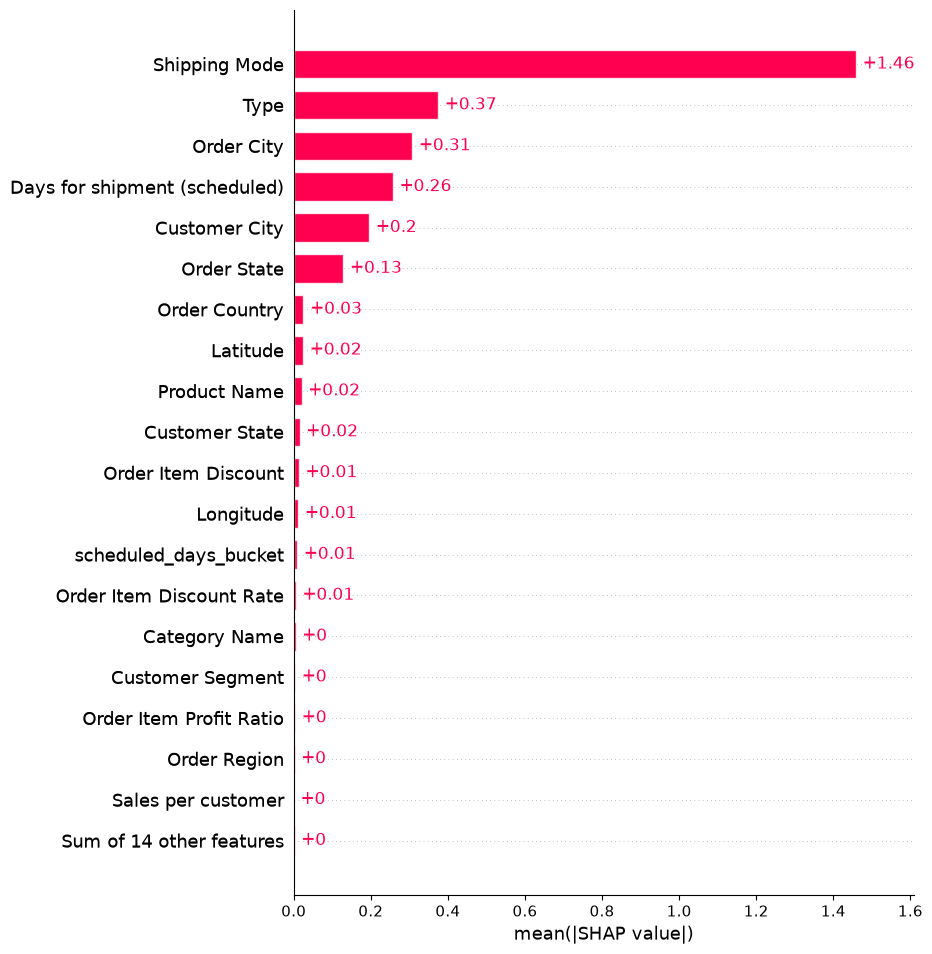

In [16]:
shap.plots.bar(
    shap_values,
    max_display=20
)

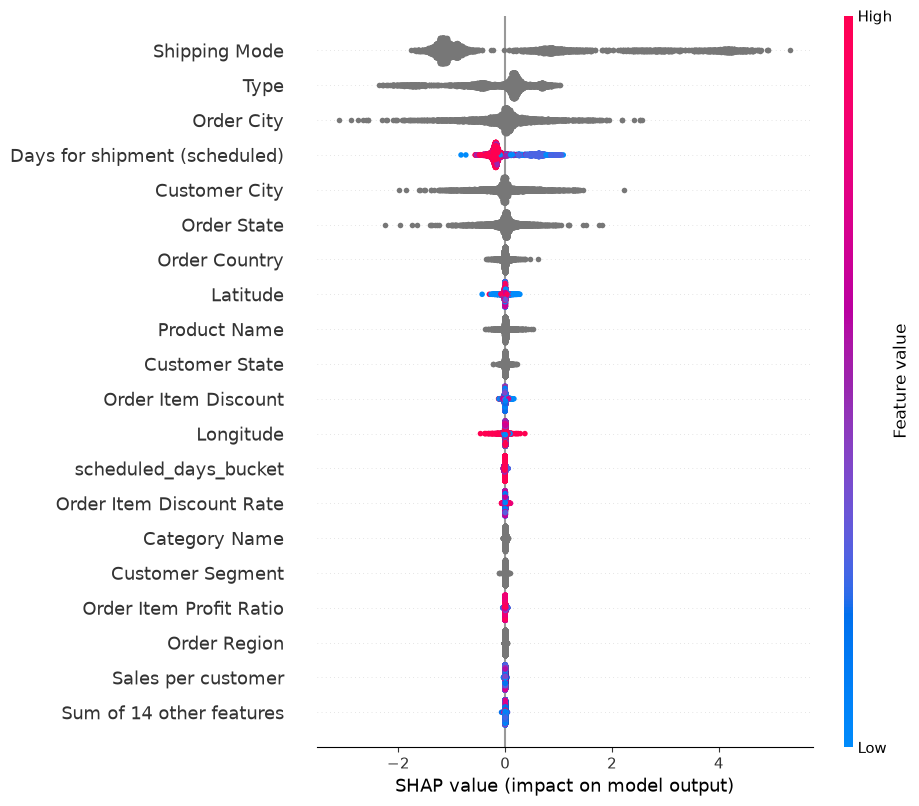

In [17]:
shap.plots.beeswarm(
    shap_values,
    max_display=20
)

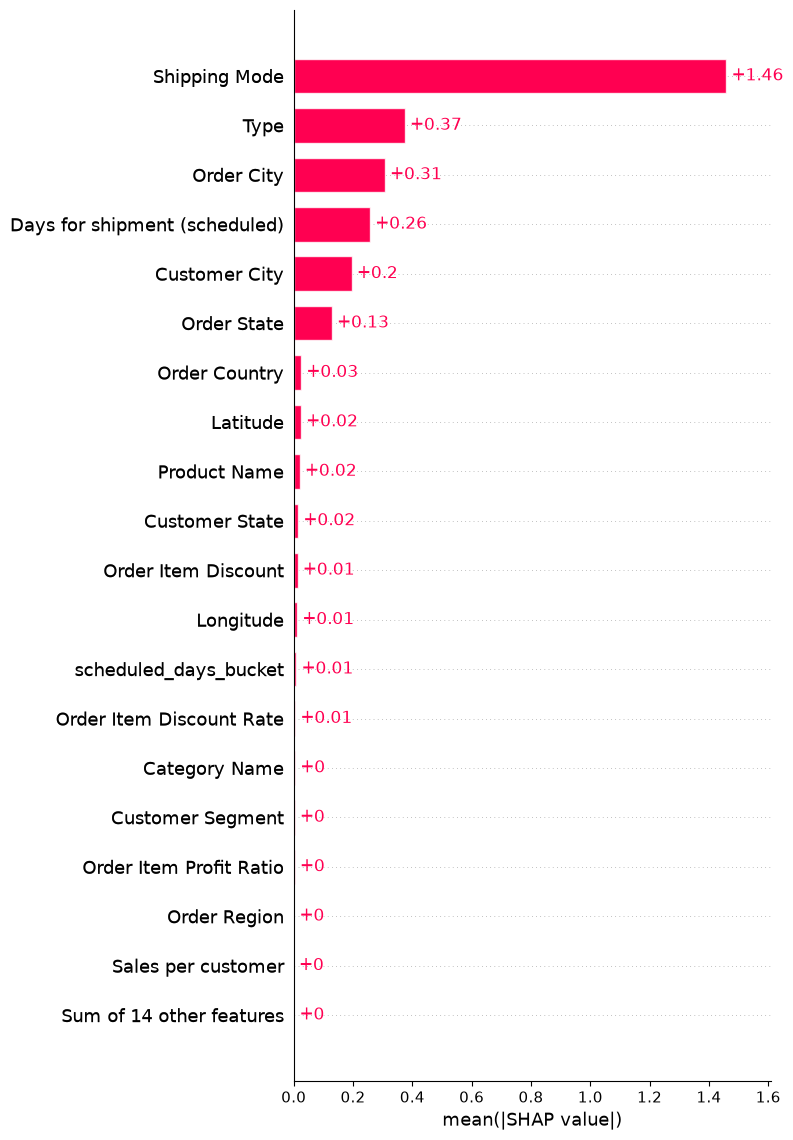

Saved: c:\Users\ganesh\Desktop\All Projects\Build Logistic Analysis Project\outputs\shap_global_importance.png


In [18]:
plt.figure()

shap.plots.bar(
    shap_values,
    max_display=20,
    show=False
)

plt.tight_layout()

shap_bar_path = OUTPUT_DIR / "shap_global_importance.png"

plt.savefig(
    shap_bar_path,
    dpi=300,
    bbox_inches= "tight"
)

plt.show()
print("Saved:", shap_bar_path)

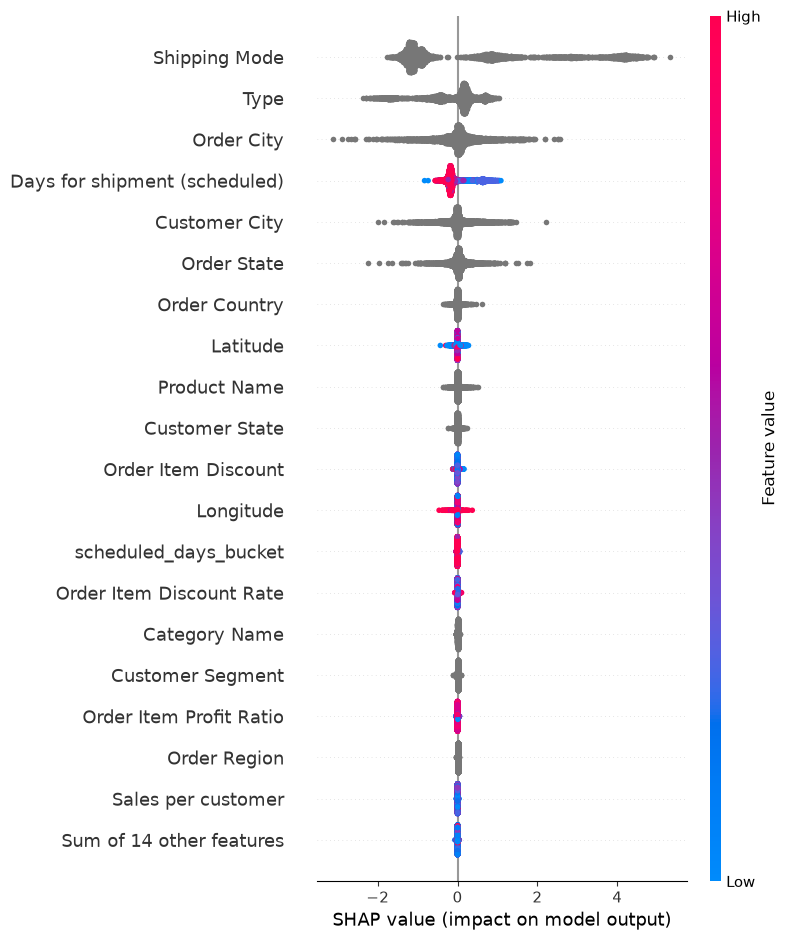

Saved: c:\Users\ganesh\Desktop\All Projects\Build Logistic Analysis Project\outputs\shap_beeswarm.png


In [19]:
plt.figure()

shap.plots.beeswarm(
    shap_values,
    max_display=20,
    show=False
)

plt.tight_layout()

shap_beesearm_path = OUTPUT_DIR / "shap_beeswarm.png"

plt.savefig(
    shap_beesearm_path,
    dpi=300,
    bbox_inches= "tight"
)

plt.show()
print("Saved:",shap_beesearm_path)

In [22]:
shap_importance = pd.DataFrame({
    "Feature": x_shap_sample.columns,
    "Mean_Absolute_SHAP": np.abs(
        shap_values.values
    ).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

shap_importance.head(20)

,Feature,Mean_Absolute_SHAP
0,Shipping Mode,1.459053
1,Type,0.374788
2,Order City,0.307524
3,Days for shipment (scheduled),0.257478
4,Customer City,0.195837
5,Order State,0.128877
6,Order Country,0.025359
7,Latitude,0.024536
8,Product Name,0.020466
9,Customer State,0.015285


In [23]:
shap_importance.to_csv(
    OUTPUT_DIR / "shap_feature_importance.csv",
    index=False
)

print("SHAP feature importance saved successfully.")

SHAP feature importance saved successfully.


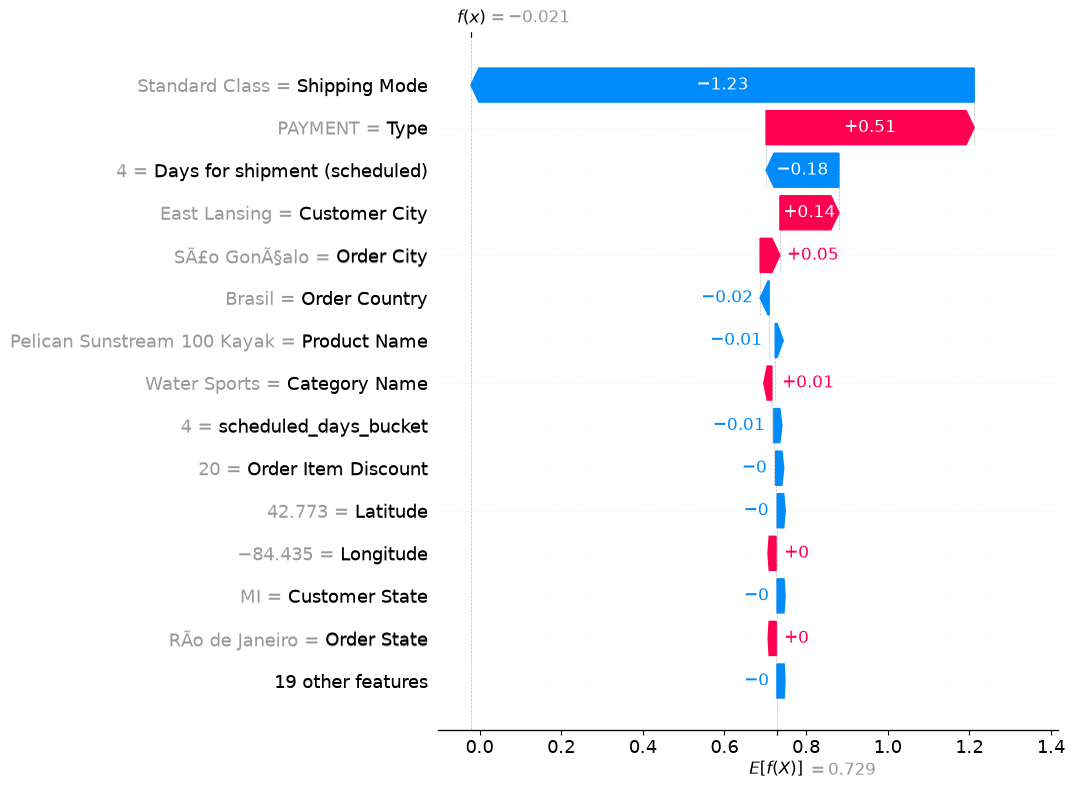

In [25]:
sample_index = 0

single_explanation = shap_values[sample_index]

shap.plots.waterfall(
    single_explanation,
    max_display = 15
)

In [26]:
sample_row = x_shap_sample.iloc[[sample_index]]

prediction = lightgbm_model.predict(
    sample_row
)[0]

probability = lightgbm_model.predict_proba(
    sample_row
)[0, 1]

print("Predicted class:",prediction)
print("Predicted late-delivery risk:", round(probability, 4))

Predicted class: 0
Predicted late-delivery risk: 0.4947
